## HW4

#### Import dataset

In [45]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

#### Create DataFrame and data info

In [46]:
import pandas as pd

cancer_data = cancer.data
feature_names = cancer.feature_names
target = cancer.target

df = pd.DataFrame(cancer_data, columns=feature_names)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

#### Descriptive statistics

In [47]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


#### Standardization

In [48]:
from sklearn.preprocessing import StandardScaler

# Initialize Scaler
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df)

# Create scaled df and check standardized values 
df_scaled = pd.DataFrame(scaled_array, columns=df.columns)
df_scaled.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


#### Scatter plot 

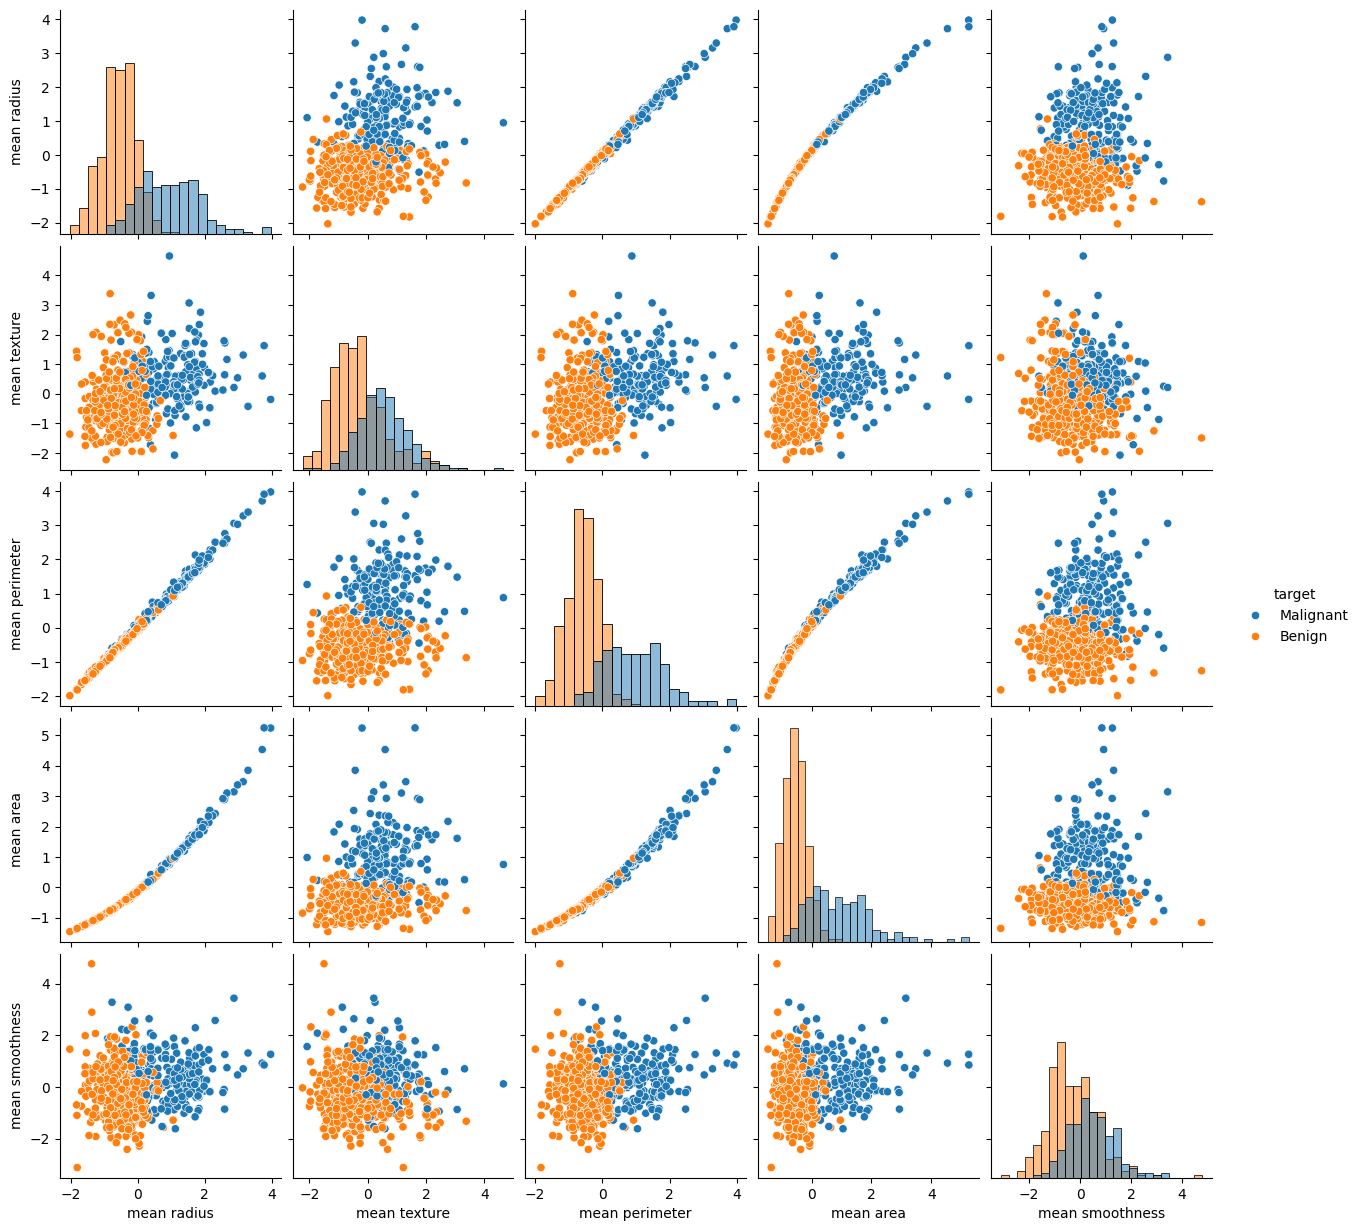

In [49]:
import seaborn as sns

#  Target names to plot
df_scaled['target'] = target
df_scaled['target'] = df_scaled['target'].map({0: 'Malignant', 1: 'Benign'})

#  Slice df to plot
feature_cols = df.columns[:5]

# Plot
sns.pairplot(df_scaled, vars=feature_cols,hue='target', palette='tab10', diag_kind='hist')

#### Distance matrix

In [50]:
import pandas as pd
from sklearn.metrics.pairwise import pairwise_distances

def distance_matrix(df, metric='euclidean'):
    numeric_columns = df.select_dtypes(include='number')

    # Calc natrix
    distance_matrix = pairwise_distances(numeric_columns, metric=metric)

    # Create DF with results
    result_df = pd.DataFrame(distance_matrix, index=numeric_columns.index, columns=numeric_columns.index)

    return result_df

dist = ['cosine', 'euclidean', 'manhattan']
# cityblock, l1, manhattan - the same

for d in dist:
    dist_matrix = distance_matrix(df_scaled, metric=d)
    print(f"{d} distance matrix result:\n")
    print(f"{dist_matrix.iloc[:5, :5]}\n")

cosine distance matrix result:

          0         1         2         3         4
0  0.000000  0.685444  0.189612  0.330272  0.411598
1  0.685444  0.000000  0.387689  1.293556  0.309409
2  0.189612  0.387689  0.000000  0.602338  0.276429
3  0.330272  1.293556  0.602338  0.000000  1.038768
4  0.411598  0.309409  0.276429  1.038768  0.000000

euclidean distance matrix result:

           0          1          2          3          4
0   0.000000  10.318497   6.777634  10.472674   8.671036
1  10.318497   0.000000   5.032015  16.250739   4.378888
2   6.777634   5.032015   0.000000  12.844721   4.462229
3  10.472674  16.250739  12.844721   0.000000  15.375300
4   8.671036   4.378888   4.462229  15.375300   0.000000

manhattan distance matrix result:

           0          1          2          3          4
0   0.000000  48.300161  31.060655  48.970723  39.730356
1  48.300161   0.000000  23.069039  73.251197  19.626260
2  31.060655  23.069039   0.000000  56.002734  17.678398
3  48.970723  

#### Distance Matrix Visualization

cosine result:


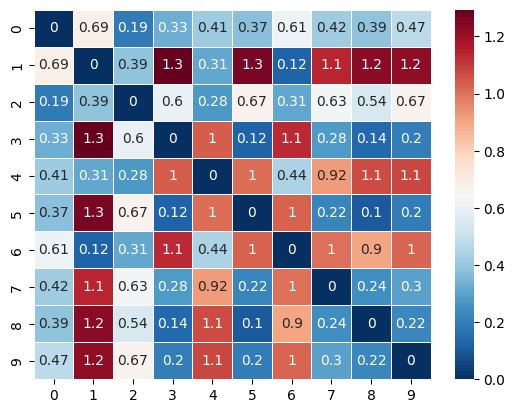

euclidean result:


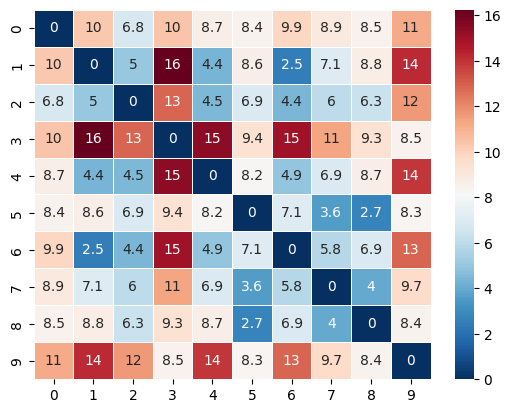

manhattan result:


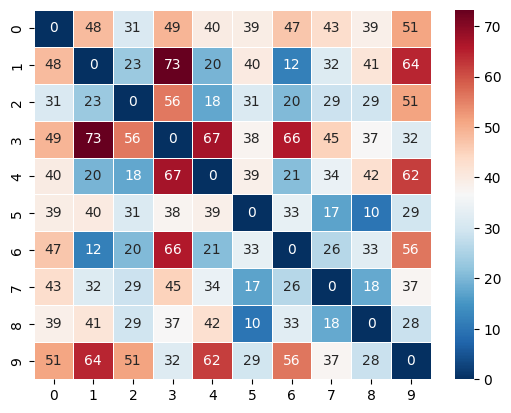

In [51]:
import matplotlib.pyplot as plt

for d in dist:
    dist_matrix = distance_matrix(df_scaled, metric=d)
    print(f"{d} result:")
    sns.heatmap(
        dist_matrix.iloc[:10, :10],
        cmap="RdBu_r",
        annot=True,
        linewidth=0.5,
    )
    plt.show()

cosine result:


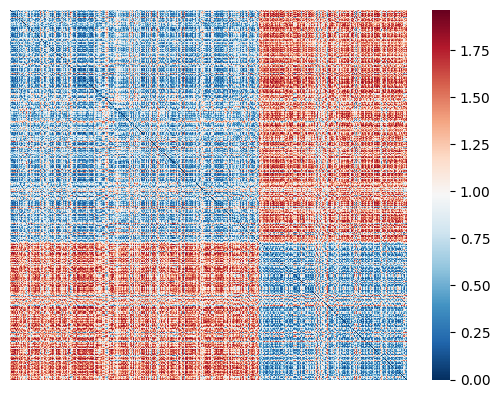

euclidean result:


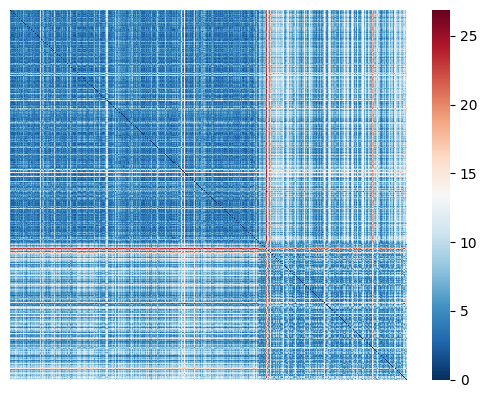

manhattan result:


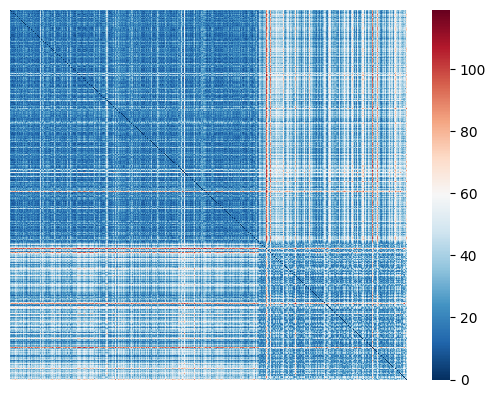

In [63]:
# Sorting df before building matrix to have visible clusters
df_sorted = df_scaled.sort_values(by="target")
data_for_matrix = df_sorted.drop(columns=["target"])

for d in dist:
    dist_matrix_all = distance_matrix(data_for_matrix, metric=d)
    print(f"{d} result:")
    sns.heatmap(
        dist_matrix_all,
        cmap="RdBu_r",
        xticklabels=False,
        yticklabels=False,
        annot=False,
    )
    plt.show()

### Conclusions

**Metrics Comparison**

*Cosine Distance:* This metric ignores the actual size of the tumor, which is a big problem in medicine. It might say that two tumors are "the same" just because they have a similar shape, even if one is much bigger and more dangerous than the other. 

*Manhattan ($L_1$):* This is more effective because it looks at the real size (area, radius, etc.). It can tell the difference between a small Benign tumor and a large Malignant one, even if their shapes look alike. But it reacts to every small change in the data (range 0—70+)

*Euclidean ($L_2$):* I found this to be the most efficient metric. It doesn't just look at the size; it focuses on the most important differences between patients (range 0—16+). 

**Comparison of Patients index 9 and index 3:**

- Manhattan (32 out of ~70) and Euclidean (8.5 out of ~16) show that these patients are actually quite different.

- However, Cosine (0.2) says they are very similar.

For medical data like Breast Cancer, Manhattan and Euclidean metrics work much better than Cosine because the physical size and scale of the tumor are very important for the diagnosis.